## Colab bootstrap

Clone the whole repo (so `core/`, `configs/`, `datasets/`, `ckpts/` are present).
Idempotent + absolute-path, so re-running never nests directories.

# BioArc — Full Tutorial (GPU version, single notebook)

**Neural Architecture Search for Biological Foundation Models** (arXiv:2512.00283).

Same end-to-end narrative as the CPU tutorial, but running on **GPU** (CUDA) for speed.
We still **skip the GPU-only Mamba block** (no `mamba_ssm` needed) — everything else
(CNN / Transformer / LSTM / Hyena) runs on the GPU.

| § | What |
|---|------|
| 1 | The heterogeneous **search space** |
| 2 | A weight-sharing **supernet** + **one-shot pretraining** on real GRCh38 DNA |
| 3 | The **discovered 8.3 M hybrid** (loaded from its pretrained checkpoint) |
| 4 | **Fine-tune & compare** — BioArc 8M vs a 50M Transformer on 3 small tasks |
| 5 | **Interpretability** — layer-wise view of the hybrid vs NT-50M (run on CPU) |

> On Colab: **Runtime → Change runtime type → GPU (T4)** before running.

In [ ]:
# Colab bootstrap
import os, shutil

#shutil.rmtree("/content/ISMB-tutorial", ignore_errors=True)

REPO = "/content/ISMB-tutorial"
if not os.path.isdir(os.path.join(REPO, ".git")):
    !git clone https://github.com/YiFang99/ISMB-tutorial.git {REPO}
%cd {REPO}

import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q "transformers==4.56.0" "tokenizers==0.22.0" einops
else:
    %pip install -q -r requirements.txt
print("dependencies ready")

Cloning into '/content/ISMB-tutorial'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 81 (delta 15), reused 4 (delta 1), pack-reused 45 (from 1)
Receiving objects: 100% (81/81), 42.58 MiB | 16.39 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/ISMB-tutorial
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
dependencies ready


## 0 · Setup (use GPU if available)

In [ ]:
import os, sys, json, random, time, copy
import numpy as np, torch, torch.nn as nn

# Auto-detect the tutorial root = the folder containing core/ + requirements.txt.
def _find_root(start):
    d = os.path.abspath(start)
    while d != os.path.dirname(d):
        if os.path.isdir(os.path.join(d, "core")) and os.path.exists(os.path.join(d, "requirements.txt")):
            return d
        d = os.path.dirname(d)
    return os.path.abspath(start)
PROJECT_DIR = _find_root(os.getcwd())
sys.path.insert(0, PROJECT_DIR)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # <-- GPU if present
torch.manual_seed(0); random.seed(0); np.random.seed(0)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(0)

from core.training_scripts.build_model import build_custom_model
from core.data_utils.mytokenizers import MyTokenizer
from core.models.modules import build_module

print("project:", PROJECT_DIR)
print("torch", torch.__version__, "| device:", DEVICE,
      "|", (torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "no GPU — will run on CPU"))
if DEVICE.type != "cuda":
    print("  (tip: Colab -> Runtime -> Change runtime type -> GPU)")

project: /content/ISMB-tutorial
torch 2.11.0+cu128 | device: cuda | Tesla T4


## 1 · The heterogeneous search space

BioArc searches over **hybrids** of different block types (CNN / Transformer / LSTM / Mamba /
Hyena), across depths and widths — because biological sequences mix local motifs, long-range
dependencies and periodicity. Even the block-type orderings alone explode combinatorially.

In [ ]:
# Read the search-space config: which block types, per-layer widths, depth range
cfg = json.load(open(f"{PROJECT_DIR}/configs/searchSpace_config/mix.json"))
blocks = cfg["architecture_list"]; depths = {int(k): v for k, v in cfg["layer_nums_dict"].items()}
print("block types:", blocks)                 # 5 block types: cnn/transformer/lstm/mamba/hyena
print("hidden dims:", cfg["hidden_dim_list"])  # candidate widths per layer
total = 0
for L in sorted(depths):
    o = len(blocks)**L; total += o
    print(f"  depth {L}: {len(blocks)}^{L} = {o:>7,d} block-type orderings")
print(f"  total (depths 3-6): {total:,d}  x width choices -> millions of architectures")

block types: ['cnn', 'transformer', 'hyena', 'lstm', 'mamba']
hidden dims: [64, 128, 256, 512]
  depth 3: 5^3 =     125 block-type orderings
  depth 4: 5^4 =     625 block-type orderings
  depth 5: 5^5 =   3,125 block-type orderings
  depth 6: 5^6 =  15,625 block-type orderings
  total (depths 3-6): 19,500  x width choices -> millions of architectures


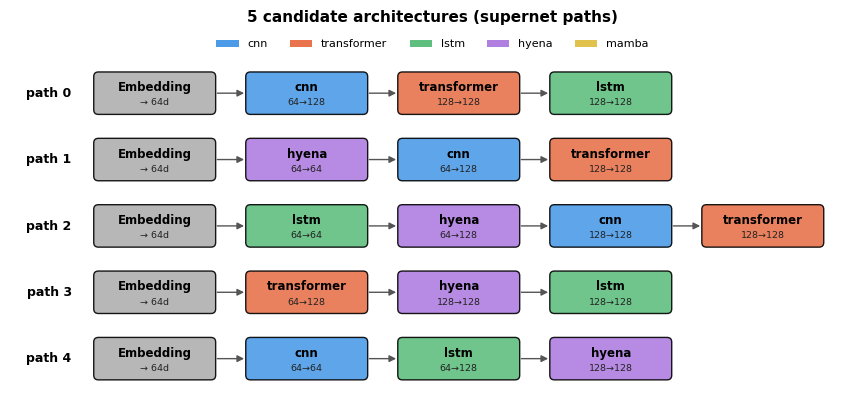

In [ ]:
# Visualize a few candidate architectures as block diagrams
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Patch
PATHS = [
        [("cnn",64,128),("transformer",128,128),("lstm",128,128)],
        [("hyena",64,64),("cnn",64,128),("transformer",128,128)],
        [("lstm",64,64),("hyena",64,128),("cnn",128,128),("transformer",128,128)],
        [("transformer",64,128),("hyena",128,128),("lstm",128,128)],
        [("cnn",64,64),("lstm",64,128),("hyena",128,128)],
]

COLORS = {"cnn":"#4C9BE8","transformer":"#E8734C","lstm":"#5FBF7F",
          "hyena":"#B07FE0","mamba":"#E0C24C","embedding":"#B0B0B0"}

# --- tuned geometry ---
BW, BH   = 1.55, 0.52
GAP      = 0.42
ROW_GAP  = 0.34
FS_TITLE = 8.5
FS_SUB   = 6.8
FS_ROW   = 9

maxlen = max(len(p) for p in PATHS) + 1
row_h  = BH + ROW_GAP
fig, ax = plt.subplots(figsize=(1.75*maxlen, 0.92*len(PATHS)))

def box(x, y, label, sub, color):
    ax.add_patch(FancyBboxPatch((x, y), BW, BH, boxstyle="round,pad=0.015,rounding_size=0.06",
                                linewidth=1.0, edgecolor="black", facecolor=color, alpha=0.9))
    ax.text(x+BW/2, y+BH*0.64, label, ha="center", va="center", fontsize=FS_TITLE, fontweight="bold")
    ax.text(x+BW/2, y+BH*0.26, sub,   ha="center", va="center", fontsize=FS_SUB, color="#222")

def arrow(x0, x1, y):
    ax.add_patch(FancyArrowPatch((x0, y+BH/2), (x1, y+BH/2), arrowstyle="-|>",
                                 mutation_scale=10, linewidth=1.0, color="#555"))

for r, path in enumerate(PATHS):
    y = (len(PATHS)-1-r) * row_h
    ax.text(-0.30, y+BH/2, f"path {r}", ha="right", va="center", fontsize=FS_ROW, fontweight="bold")
    box(0.0, y, "Embedding", f"→ {path[0][1]}d", COLORS["embedding"])
    prev_right = BW
    for (t, a, b) in path:
        x = prev_right + GAP
        arrow(prev_right, x, y)
        box(x, y, t, f"{a}→{b}", COLORS.get(t, "#CCC"))
        prev_right = x + BW

ax.set_xlim(-1.1, maxlen*(BW+GAP)); ax.set_ylim(-0.25, len(PATHS)*row_h)
ax.set_aspect("equal"); ax.axis("off")

types = [t for t in COLORS if t != "embedding"]
ax.legend(handles=[Patch(facecolor=COLORS[t], label=t) for t in types],
          loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=len(types), fontsize=8, frameon=False)
ax.set_title("5 candidate architectures (supernet paths)", fontsize=11, fontweight="bold", pad=18)
plt.tight_layout(); plt.show()


## 2 · Weight-sharing supernet + one-shot pretraining (GPU toy)

> **Toy scale:** we hand-pick **5 candidate architectures** ("paths") and train for **60 steps**.
> The real BioArc searches **thousands** of paths (incl. Mamba) and pretrains ~**300k steps**.

We fold the 5 paths into one **supernet** with shared blocks, and train it on the GPU
(masked-LM: guess 15% hidden DNA letters). We still **skip Mamba** — the 5 paths use only
CNN / Transformer / LSTM / Hyena.

In [ ]:
# -- Setup: tokenizer + a little real DNA data --
tok = MyTokenizer(PROJECT_DIR, "DNA", "kmer1")
PAD, MASK, VOCAB = tok.token_to_id("[PAD]"), tok.token_to_id("[MASK]"), tok.vocab_size
seqs = []
with open(f"{PROJECT_DIR}/datasets/GRCh38/processed_data_short/all_sentences.jsonl") as f:
    for i, line in enumerate(f):
        if i >= 96: break
        seqs.append(json.loads(line)["text"].upper())
print(f"loaded {len(seqs)} DNA sequences | vocab size = {VOCAB} (A/C/G/T + special tokens)")
print(f"  example: {seqs[0][:50]}...")

# 5 candidate architectures (no Mamba)
PATHS = [
    [("cnn",64,128),("transformer",128,128),("lstm",128,128)],
    [("hyena",64,64),("cnn",64,128),("transformer",128,128)],
    [("lstm",64,64),("hyena",64,128),("cnn",128,128),("transformer",128,128)],
    [("transformer",64,128),("hyena",128,128),("lstm",128,128)],
    [("cnn",64,64),("lstm",64,128),("hyena",128,128)],
]
print("\nthe 5 candidate architectures (paths):")
for i, p in enumerate(PATHS):
    print(f"  path {i}: " + " -> ".join(f"{t}({a}->{b})" for (t,a,b) in p))

# weight sharing: same (type,in,out) -> one shared module
from collections import Counter
pool = nn.ModuleDict()
def _k(t,i,o): return f"{t}_{i}_{o}"
for p in PATHS:
    for c in p:
        if _k(*c) not in pool:
            pool[_k(*c)] = build_module(*c)
paths = [nn.Sequential(*[pool[_k(*c)] for c in p]) for p in PATHS]

usage = Counter(_k(*c) for p in PATHS for c in p)
print(f"\nshared block pool: {len(pool)} distinct blocks serve {sum(usage.values())} slots across the 5 paths")
for name, module in pool.items():
    npar = sum(x.numel() for x in module.parameters())
    tag = f"   <- shared by {usage[name]} paths" if usage[name] > 1 else ""
    print(f"  {name:22s} {npar:>7,d} params{tag}")

emb_s = nn.Embedding(VOCAB, 64, padding_idx=PAD)
head_s = nn.Linear(128, VOCAB)

# >>> move the whole supernet to the GPU <<<
emb_s = emb_s.to(DEVICE); head_s = head_s.to(DEVICE); pool = pool.to(DEVICE)

ntot = sum(x.numel() for x in list(emb_s.parameters())+list(pool.parameters())+list(head_s.parameters()))
print(f"\nsupernet total params: {ntot/1e6:.3f} M  (on {DEVICE})")

# masked-LM task (batches are created directly on DEVICE)
def mb(bs=8, Lb=32):
    ids = [torch.tensor(tok.encode(s).ids[:Lb]) for s in random.sample(seqs, bs)]
    ids = torch.nn.utils.rnn.pad_sequence(ids, batch_first=True, padding_value=PAD)
    tgt = torch.full_like(ids, PAD); m = torch.rand(ids.shape) < 0.15
    tgt[m] = ids[m]
    ids = ids.clone(); ids[m] = MASK
    return ids.to(DEVICE), tgt.to(DEVICE)

def run(pi, ids):
    return head_s(paths[pi](emb_s(ids)))
lossfn = nn.CrossEntropyLoss(ignore_index=PAD)

ev_ids, ev_tgt = mb(16, 32)
def per_path_loss():
    with torch.no_grad():
        return [lossfn(run(pi, ev_ids).permute(0,2,1), ev_tgt).item() for pi in range(len(paths))]

loaded 96 DNA sequences | vocab size = 9 (A/C/G/T + special tokens)
  example: ACAGTGTCTCAGGCCTGTAATCTCAGCACTTTCGGAGGCGGAGACGGATG...

the 5 candidate architectures (paths):
  path 0: cnn(64->128) -> transformer(128->128) -> lstm(128->128)
  path 1: hyena(64->64) -> cnn(64->128) -> transformer(128->128)
  path 2: lstm(64->64) -> hyena(64->128) -> cnn(128->128) -> transformer(128->128)
  path 3: transformer(64->128) -> hyena(128->128) -> lstm(128->128)
  path 4: cnn(64->64) -> lstm(64->128) -> hyena(128->128)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)



shared block pool: 11 distinct blocks serve 16 slots across the 5 paths
  cnn_64_128              74,112 params   <- shared by 2 paths
  transformer_128_128    198,528 params   <- shared by 3 paths
  lstm_128_128           132,096 params   <- shared by 2 paths
  hyena_64_64             69,696 params
  lstm_64_64              33,280 params
  hyena_64_128           231,232 params
  cnn_128_128            147,840 params
  transformer_64_128     206,848 params
  hyena_128_128          222,912 params   <- shared by 2 paths
  cnn_64_64               37,056 params
  lstm_64_128             99,328 params

supernet total params: 1.455 M  (on cuda)


### Run the one-shot pretraining

In [ ]:
# -- One-shot pretraining: each step trains 1 random path, 60 steps total --
from collections import Counter
opt = torch.optim.AdamW(list(emb_s.parameters())+list(pool.parameters())+list(head_s.parameters()), lr=1e-3)
before_list = per_path_loss()
sampled = Counter()
print("training (one-shot: sample 1 random path per step):")
for step in range(60):
    ids, tgt = mb()
    pi = random.randrange(len(paths))
    sampled[pi] += 1
    loss = lossfn(run(pi, ids).permute(0,2,1), tgt)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 10 == 0 or step == 59:
        print(f"  step {step:2d} | trained path {pi} | loss on that path = {loss.item():.3f}")
after_list = per_path_loss()
print("  times each path was sampled:", dict(sorted(sampled.items())))

print("\nmasked-LM loss per path  (before -> after):")
for i,(b,a) in enumerate(zip(before_list, after_list)):
    print(f"  path {i}: {b:.3f} -> {a:.3f}   (down {b-a:+.3f})")
before, after = float(np.mean(before_list)), float(np.mean(after_list))
print(f"  MEAN over ALL 5 paths: {before:.3f} -> {after:.3f}")
print("=> only ONE random path was trained per step, yet ALL 5 improved -> that's weight sharing.")

training (one-shot: sample 1 random path per step):
  step  0 | trained path 0 | loss on that path = 2.150
  step 10 | trained path 4 | loss on that path = 1.364
  step 20 | trained path 1 | loss on that path = 1.633
  step 30 | trained path 2 | loss on that path = 1.614
  step 40 | trained path 1 | loss on that path = 1.521
  step 50 | trained path 4 | loss on that path = 1.369
  step 59 | trained path 4 | loss on that path = 1.407
  times each path was sampled: {0: 11, 1: 13, 2: 9, 3: 8, 4: 19}

masked-LM loss per path  (before -> after):
  path 0: 2.175 -> 1.325   (down +0.850)
  path 1: 2.422 -> 1.312   (down +1.110)
  path 2: 2.251 -> 1.329   (down +0.923)
  path 3: 2.244 -> 1.343   (down +0.901)
  path 4: 2.200 -> 1.368   (down +0.832)
  MEAN over ALL 5 paths: 2.258 -> 1.335
=> only ONE random path was trained per step, yet ALL 5 improved -> that's weight sharing.


## 3 · The discovered hybrid architecture

The ~8.3 M hybrid BioArc discovered, loaded from its pretrained checkpoint and moved to the GPU.

In [ ]:
# -- Load the architecture BioArc discovered (the ~8.3M hybrid) --
NC = 2
CKPT = f"{PROJECT_DIR}/ckpts/DNA_8M.ckpt"
bio, _ = build_custom_model(PROJECT_DIR, "kmer1", NC, checkpoint_path=CKPT)
bio = bio.to(DEVICE).eval()
print("architecture:", " -> ".join(type(m).__name__ for m in bio.path))
print(f"parameters  : {sum(p.numel() for p in bio.parameters())/1e6:.2f} M")

import csv as _csv0
with open(f"{PROJECT_DIR}/datasets/core_promoter/test.csv") as _f:
    demo_seq = next(r[0] for r in _csv0.reader(_f) if r and r[0] != "sequence")
btok = MyTokenizer(PROJECT_DIR, "DNA", "kmer1")
ids0 = torch.tensor(btok.encode(demo_seq).ids).unsqueeze(0).to(DEVICE); m0 = torch.ones_like(ids0)
with torch.no_grad(): logit, feat, _ = bio(ids0, m0)
print(f"forward on one Core Promoter seq: {tuple(ids0.shape)} tokens -> feature {tuple(feat.shape)} ({DEVICE})")

  Pretrained Model Loaded
architecture: HyenaModule -> TransformerModule -> TransformerModule -> CNNModule -> CNNModule -> CNNModule
parameters  : 8.32 M
forward on one Core Promoter seq: (1, 70) tokens -> feature (1, 512) (cuda)


## 4 · Fine-tune & compare: BioArc 8M vs a 50M Transformer (on GPU)

Both models are fine-tuned on the GPU, so this is much faster than the CPU tutorial.
You can raise `N_TR / N_TE / EP` for stronger numbers now that it runs on GPU.

In [ ]:
# -- GPU fine-tuning: BioArc 8M vs NT-50M, on 3 small tasks --
from core.data_utils.mytokenizers import MyTokenizer
from core.models.training_utils import build_cls_collate, set_seed
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForMaskedLM
import csv as _csv
from tqdm.auto import tqdm      # progress bars

DATASETS = {
    "core_promoter (interp. task)": "datasets/core_promoter",
    "human_nontata_promoters":      "datasets/GB/human_nontata_promoters",
    "demo_coding_vs_intergenomic":  "datasets/GB/demo_coding_vs_intergenomic_seqs",
}
N_TR, N_TE = 2000, 1000          # int, or "FULL" to use ALL train/test rows
EP, BS     = 3, 64
LR_BIO     = 5e-4              # BioArc 8M learning rate
LR_NT      = 5e-4              # NT-50M learning rate (large pretrained FM -> smaller LR)

tokB = MyTokenizer(PROJECT_DIR, "DNA", "kmer1"); PADB = tokB.token_to_id("[PAD]")
_MID = "InstaDeepAI/nucleotide-transformer-v2-50m-multi-species"
_ntok = AutoTokenizer.from_pretrained(_MID, trust_remote_code=True)

def _load(relpath, split):
    seqs, labs = [], []
    for r in _csv.reader(open(f"{PROJECT_DIR}/{relpath}/{split}.csv")):
        if r and r[0] != "sequence": seqs.append(r[0]); labs.append(int(r[1]))
    return seqs, labs

def _subset(relpath):
    trs, trl = _load(relpath, "train"); tes, tel = _load(relpath, "test")
    random.seed(0)
    ti = list(range(len(trs))); random.shuffle(ti)
    if N_TR != "FULL": ti = ti[:N_TR]
    vi = list(range(len(tes))); random.shuffle(vi)
    if N_TE != "FULL": vi = vi[:N_TE]
    return [trs[i] for i in ti], [trl[i] for i in ti], [tes[i] for i in vi], [tel[i] for i in vi]

class _SeqDS(torch.utils.data.Dataset):
    def __init__(s, seqs, labs): s.seqs=seqs; s.labs=labs; s.pad_idx=PADB
    def __len__(s): return len(s.seqs)
    def __getitem__(s, i):
        x = torch.tensor(tokB.encode(s.seqs[i]).ids); return x, torch.tensor(s.labs[i]), len(x)

class _NTClf(nn.Module):
    def __init__(s, enc, h): super().__init__(); s.enc=enc; s.head=nn.Linear(h, 2)
    def forward(s, ids, mask):
        o = s.enc(input_ids=ids, attention_mask=mask).last_hidden_state
        m = mask.unsqueeze(-1).float(); return s.head((o*m).sum(1)/m.sum(1))

def ft_bioarc(trs, trl, tes, tel):
    coll = build_cls_collate(PADB)
    tl = DataLoader(_SeqDS(trs, trl), batch_size=BS, shuffle=True, collate_fn=coll)
    vl = DataLoader(_SeqDS(tes, tel), batch_size=32, collate_fn=coll)
    set_seed(0)
    m, _ = build_custom_model(PROJECT_DIR, "kmer1", 2, checkpoint_path=CKPT); m = m.to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(), lr=LR_BIO, weight_decay=0.1); lf = nn.CrossEntropyLoss()
    def acc():
        m.eval(); c = n = 0
        with torch.no_grad():
            for x, y, mm in vl:
                x, y, mm = x.to(DEVICE), y.to(DEVICE), mm.to(DEVICE)
                c += (m(x, mm)[0].argmax(1) == y).sum().item(); n += len(y)
        return c / n
    best = acc()
    for ep in range(EP):
        m.train()
        pbar = tqdm(tl, desc=f"BioArc ep{ep+1}/{EP}", leave=False)
        for x, y, mm in pbar:
            x, y, mm = x.to(DEVICE), y.to(DEVICE), mm.to(DEVICE)
            opt.zero_grad(); loss = lf(m(x, mm)[0], y); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
            pbar.set_postfix(loss=f"{loss.item():.3f}")
        best = max(best, acc())
    return best, m

def ft_nt50m(trs, trl, tes, tel):
    set_seed(0)
    enc = AutoModelForMaskedLM.from_pretrained(_MID, trust_remote_code=True).esm
    clf = _NTClf(enc, enc.config.hidden_size).to(DEVICE)
    opt = torch.optim.AdamW(clf.parameters(), lr=LR_NT, weight_decay=0.01); lf = nn.CrossEntropyLoss()
    def bat(S, Ls, shuf=False):
        order = list(range(len(S)))
        if shuf: random.shuffle(order)
        for i in range(0, len(order), BS):
            ii = order[i:i+BS]; s = [S[j] for j in ii]; y = torch.tensor([Ls[j] for j in ii])
            b = _ntok(s, return_tensors="pt", padding=True, truncation=True, max_length=64)
            yield b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE), y.to(DEVICE)
    def acc():
        clf.eval(); c = n = 0
        with torch.no_grad():
            for ids, mask, y in bat(tes, tel): c += (clf(ids, mask).argmax(1) == y).sum().item(); n += len(y)
        return c / n
    best = acc()
    nbatch = (len(trs) + BS - 1) // BS
    for ep in range(EP):
        clf.train()
        pbar = tqdm(bat(trs, trl, shuf=True), total=nbatch, desc=f"NT-50M ep{ep+1}/{EP}", leave=False)
        for ids, mask, y in pbar:
            opt.zero_grad(); loss = lf(clf(ids, mask), y); loss.backward()
            nn.utils.clip_grad_norm_(clf.parameters(), 1.0); opt.step()
            pbar.set_postfix(loss=f"{loss.item():.3f}")
        best = max(best, acc())
    return best, clf

print(f"GPU fine-tuning on {DEVICE} | {N_TR} train / {N_TE} test / {EP} epochs | lr(bio)={LR_BIO} lr(nt)={LR_NT}\n")
rows = []; kept = None
for name, path in DATASETS.items():
    trs, trl, tes, tel = _subset(path)
    print(f"[{name}]  seq={len(trs[0])}bp  fine-tuning BioArc 8M and NT-50M ...", flush=True)
    b, bio_m = ft_bioarc(trs, trl, tes, tel); n, nt_clf = ft_nt50m(trs, trl, tes, tel)
    rows.append((name, b, n)); print(f"   BioArc 8M = {b:.3f} | NT-50M = {n:.3f}", flush=True)
    if kept is None: kept = (name, path, bio_m, nt_clf, tes, tel)   # keep the SAME 500-row test subset

print("\n" + "="*54)
print(f"{'dataset':34}{'BioArc 8M':>10}{'NT-50M':>8}")
print("-"*54)
for name, b, n in rows:
    print(f"{name:34}{b:>10.3f}{n:>8.3f}")
print("="*54)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

GPU fine-tuning on cuda | 2000 train / 1000 test / 3 epochs | lr(bio)=0.0005 lr(nt)=0.0005

[core_promoter (interp. task)]  seq=70bp  fine-tuning BioArc 8M and NT-50M ...
  Pretrained Model Loaded


...

BioArc ep3/3:   0%|          | 0/32 [00:00<?, ?it/s]

NT-50M ep1/3:   0%|          | 0/32 [00:00<?, ?it/s]

NT-50M ep2/3:   0%|          | 0/32 [00:00<?, ?it/s]

NT-50M ep3/3:   0%|          | 0/32 [00:00<?, ?it/s]

   BioArc 8M = 0.901 | NT-50M = 0.842

dataset                            BioArc 8M  NT-50M
------------------------------------------------------
core_promoter (interp. task)           0.808   0.704
human_nontata_promoters                0.836   0.759
demo_coding_vs_intergenomic            0.901   0.842


## 5 · Layer-wise interpretation on the Core Promoter task (paper Fig. 4)

We find all cases where NT is wrong and BioArc is right for visualization comparison.

In [ ]:
# --- collect plotting candidates on GPU (batched), THEN move models to CPU for §5 ---
INTERP_TASK, _ipath, bio, _ntclf, _tes, _tel = kept   # _tes/_tel = the finetune test subset (not full test)
btok = tokB; enc = _ntclf.enc; hN = _ntclf.head; ntok = _ntok

# Fast BATCHED scan on the GPU (do it BEFORE moving to CPU): predict the whole subset in batches.
SCAN_BS = 128
@torch.no_grad()
def _bio_preds(seqs):
    bio.eval(); coll = build_cls_collate(PADB)
    dl = DataLoader(_SeqDS(seqs, [0]*len(seqs)), batch_size=SCAN_BS, collate_fn=coll)
    out = []
    for x, y, mm in dl:
        x, mm = x.to(DEVICE), mm.to(DEVICE)
        out.append(bio(x, mm)[0].argmax(1).cpu())
    return torch.cat(out).tolist()
@torch.no_grad()
def _nt_preds(seqs):
    _ntclf.eval(); out = []
    for i in range(0, len(seqs), SCAN_BS):
        b = ntok(seqs[i:i+SCAN_BS], return_tensors="pt", padding=True, truncation=True, max_length=64)
        ids, mask = b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE)
        out.append(_ntclf(ids, mask).argmax(1).cpu())
    return torch.cat(out).tolist()

bio = bio.to(DEVICE); _ntclf = _ntclf.to(DEVICE)
_bp, _np_ = _bio_preds(_tes), _nt_preds(_tes)

# collect every case (BioArc correct & NT-50M wrong)
CASES = [{"idx": i, "label": _tel[i], "seq": _tes[i]}
         for i in range(len(_tes)) if _bp[i] == _tel[i] and _np_[i] != _tel[i]]
CASE_IDS = [c["idx"] for c in CASES]
print(f"found {len(CASES)} cases (BioArc correct & NT-50M wrong) / {len(_tes)} test rows")
print("  case ids:", CASE_IDS[:50], "..." if len(CASE_IDS) > 50 else "")


# NOW move to CPU for the IL interpretation section (§5 runs on CPU tensors)
bio = bio.cpu().eval(); _ntclf = _ntclf.cpu().eval()
enc = _ntclf.enc; hN = _ntclf.head

found 198 cases (BioArc correct & NT-50M wrong) / 1000 test rows
  case ids: [4, 6, 7, 8, 10, 11, 14, 22, 32, 45, 48, 56, 59, 69, 72, 77, 83, 84, 88, 89, 91, 93, 94, 97, 98, 99, 100, 104, 111, 113, 118, 121, 123, 125, 126, 131, 132, 147, 155, 173, 176, 196, 205, 206, 207, 208, 215, 217, 220, 226] ...


###Pick a case

In [ ]:
print(f"Choose a number from 0 to {len(CASE_IDS)-1}")
PICK = CASE_IDS[4]
DP, DP_LABEL = _tes[PICK], _tel[PICK]
print(f"plotting case idx={PICK} | label={DP_LABEL}")

Choose a number from 0 to 197
plotting case idx=10 | label=0


### How BioArc Architecture understand a case

The waves and the blocks represents where the model is looking into.

Layer-wise interpretation of the fine-tuned BioArc 8M on one Core Promoter sequence
  true label = 0 | layers = hyena -> transformer -> transformer -> cnn -> cnn -> cnn
  (Inr/MTE/DPE promoter elements + TSS are shaded/marked


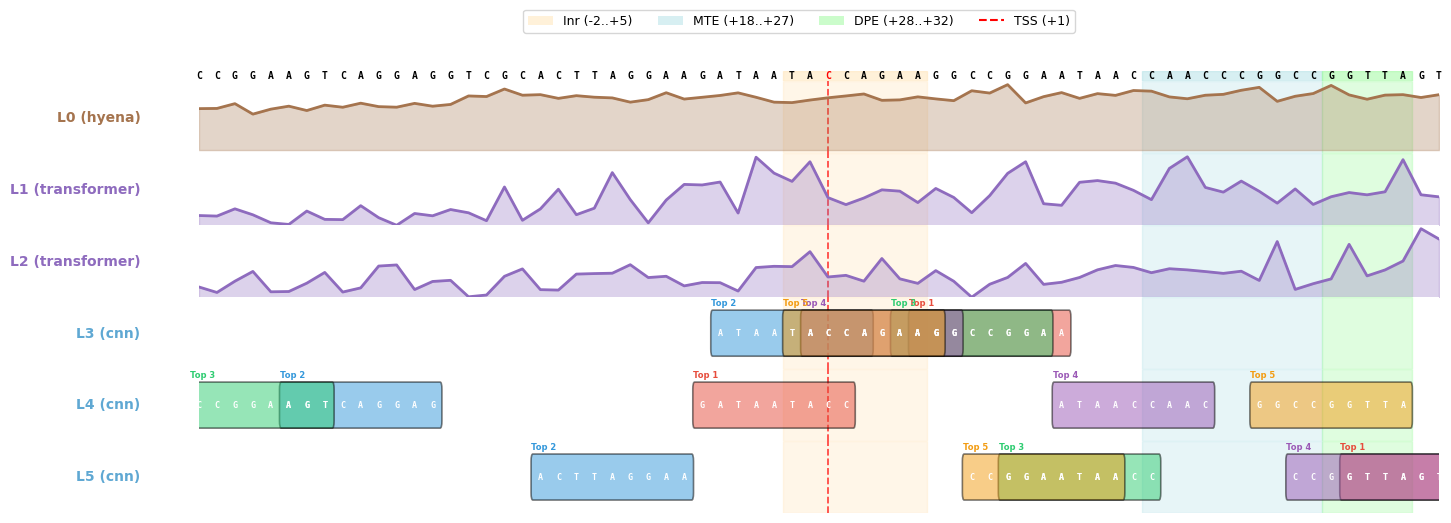

In [ ]:
from core.interpretation import interp_layers as IL


x = torch.tensor(btok.encode(DP).ids).unsqueeze(0)
acts, attns, info = IL.extract_layer_activations(bio, x)
cnn_top = IL.extract_gradcam(bio, x)
L = len(DP); TSS = L // 2

print(f"Layer-wise interpretation of the fine-tuned BioArc 8M on one Core Promoter sequence")
print(f"  true label = {DP_LABEL} | layers = " + " -> ".join(info['by_index'][i]['type'] for i in sorted(info['by_index'])))
print("  (Inr/MTE/DPE promoter elements + TSS are shaded/marked")

fig, nL = IL.plot_layers(acts, attns, info, L, DP, save_path=None, cnn_top=cnn_top, tss=TSS)
import matplotlib.pyplot as plt; plt.show()


### For comparison — what does NT-50M see?

saliency = what drove NT's decision

attn->CLS = where it looks

NT-50M on the same sequence: predicted 1 (true 0) -> WRONG


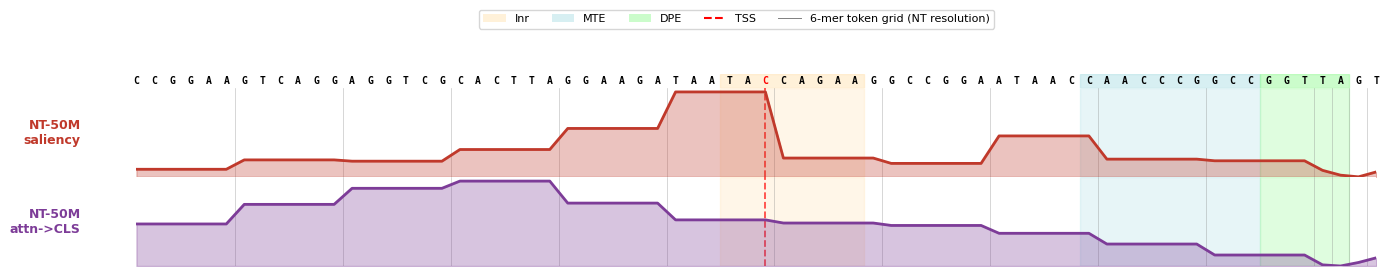

In [ ]:
# NT-50M on the SAME sequence (CPU), for comparison
nt_res = IL.analyze_nt(enc, hN, ntok, DP)
verdict = "CORRECT" if nt_res["pred"] == DP_LABEL else "WRONG"
print(f"NT-50M on the same sequence: predicted {nt_res['pred']} (true {DP_LABEL}) -> {verdict}")

fig2 = IL.plot_nt(nt_res, L, DP, tss=TSS, save_path=None)
plt.show()